In [19]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics.pairwise import cosine_similarity

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

In [20]:
CSV_PATH = "/kaggle/input/notebooks/sumedhabhadauria/01-dataset-preparation/clean_metadata.csv"
EMBEDDINGS_PATH = "/kaggle/input/notebooks/sumedhabhadauria/03-resnet50-feature-extraction/embeddings.npy"
IMAGE_IDS_PATH = "/kaggle/input/notebooks/sumedhabhadauria/03-resnet50-feature-extraction/image_ids.pkl"
MODEL_PATH = "/kaggle/input/notebooks/sumedhabhadauria/03-resnet50-feature-extraction/feature_extractor.keras"
IMAGE_FOLDER = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images")

In [21]:
df = pd.read_csv(CSV_PATH)
embeddings = np.load(EMBEDDINGS_PATH)
with open(IMAGE_IDS_PATH, "rb") as f:
    image_ids = pickle.load(f)
feature_extractor = load_model(MODEL_PATH)
print("Products      :", len(df))
print("Embeddings    :", embeddings.shape)
print("Image IDs     :", len(image_ids))

Products      : 44419
Embeddings    : (44419, 2048)
Image IDs     : 44419


In [22]:
def extract_feature(img_path):
    img = image.load_img(
        img_path,
        target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img,axis=0)
    img = preprocess_input(img)

    feature = feature_extractor.predict(
        img,
        verbose=0
    ).flatten()
    feature = feature/np.linalg.norm(feature)
    return feature

In [23]:
def recommend(query_image, top_k=5):
    query_feature = extract_feature(query_image)
    similarities = cosine_similarity(
        [query_feature],
        embeddings
    )[0]
    indices = np.argsort(similarities)[::-1]
    recommendations = []

    for idx in indices:
        image_id = image_ids[idx]
        if str(image_id) == Path(query_image).stem:
            continue
        recommendations.append(
            (
                image_id,
                similarities[idx]
            )
        )
        if len(recommendations) == top_k:
            break
    return recommendations

In [24]:
def show_results(query_image, recommendations):
    plt.figure(figsize=(16, 8))
    plt.subplot(2, 3, 1)
    plt.imshow(Image.open(query_image))
    plt.title("Query Image")
    plt.axis("off")

    for i, (image_id, score) in enumerate(recommendations):
        img_path = IMAGE_FOLDER / f"{image_id}.jpg"
        row = df[df["id"] == int(image_id)].iloc[0]
        plt.subplot(2, 3, i + 2)
        plt.imshow(Image.open(img_path))
        plt.title(
            f"{row['articleType']}\n{score*100:.2f}%",
            fontsize=10
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [25]:
query_image = IMAGE_FOLDER / "15970.jpg"
print(query_image)

/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/15970.jpg


In [26]:
recommendations = recommend(query_image)
recommendations

[(15971, np.float32(0.94005215)),
 (16408, np.float32(0.9364182)),
 (16395, np.float32(0.9340358)),
 (18327, np.float32(0.9329282)),
 (13860, np.float32(0.9318357))]

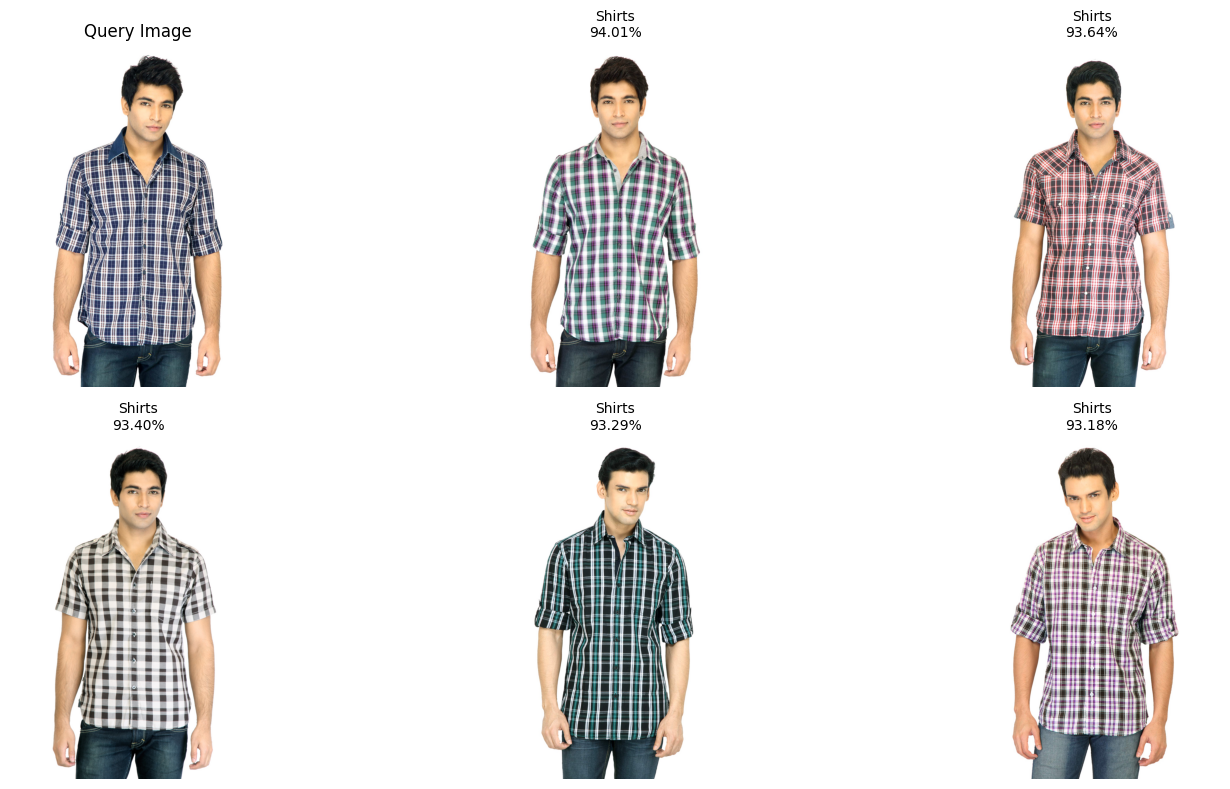

In [27]:
show_results(
    query_image,
    recommendations
)

In [28]:
results = []
for image_id, score in recommendations:
    row = df[df["id"] == int(image_id)].iloc[0]
    results.append({
        "Image ID": image_id,
        "Similarity (%)": round(score * 100, 2),
        "Gender": row["gender"],
        "Category": row["masterCategory"],
        "Sub Category": row["subCategory"],
        "Article": row["articleType"],
        "Colour": row["baseColour"]
    })
pd.DataFrame(results)

,Image ID,Similarity (%),Gender,Category,Sub Category,Article,Colour
0,15971,94.010002,Men,Apparel,Topwear,Shirts,Green
1,16408,93.639999,Men,Apparel,Topwear,Shirts,Red
2,16395,93.400002,Men,Apparel,Topwear,Shirts,Black
3,18327,93.290001,Men,Apparel,Topwear,Shirts,Black
4,13860,93.180000,Men,Apparel,Topwear,Shirts,Purple
